# 03 · Analysis 1: operating expectations strengthened, investment did not

**Question for a stakeholder:** are Canadian businesses more optimistic than they were three months
ago?

**Measure:** the directly observed share expecting an **increase**, at the Canada / all-industries
level, for each of the four metrics.

**Why this measure:** it is what the survey actually reports, it is comparable quarter to quarter,
and it needs no imputation, notebook `01` showed the missing values cannot be reconstructed and
notebook `02` showed the response shares are not a closed partition.

## Setup

In [ ]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


In [ ]:
csbc_data = csbc.load_combined()
QUARTERS = csbc.sort_quarters(csbc_data["Quarter"])

print(f"{len(csbc_data):,} rows | quarters: {', '.join(QUARTERS)}")

9,408 rows | quarters: Q3 2023, Q4 2023, Q1 2024, Q2 2024


## The national series

In [ ]:
national = csbc.national_increase_table(csbc_data)

# Every value here must be observed - this analysis never reports an imputed number.
assert national.notna().all().all(), "Analysis 1 requires an observed value in every cell."
national

Business_information,Sales,Employment,Profitability,Investment
Quarter,,,,
Q3 2023,18.4,11.6,10.7,19.4
Q4 2023,15.7,10.5,9.0,18.0
Q1 2024,17.8,11.1,11.2,17.6
Q2 2024,20.7,13.2,13.3,17.6


## Quarter-over-quarter change

In [ ]:
change = pd.DataFrame({
    "Q1 2024": national.loc["Q1 2024"],
    "Q2 2024": national.loc["Q2 2024"],
})
change["change (pp)"] = (change["Q2 2024"] - change["Q1 2024"]).round(1)
# Flag whether Q2 is the best reading in the window, not just better than last quarter.
change["four-quarter high"] = national.max() == national.loc["Q2 2024"]
change

,Q1 2024,Q2 2024,change (pp),four-quarter high
Business_information,,,,
Sales,17.8,20.7,2.9,True
Employment,11.1,13.2,2.1,True
Profitability,11.2,13.3,2.1,True
Investment,17.6,17.6,0.0,False


## Chart

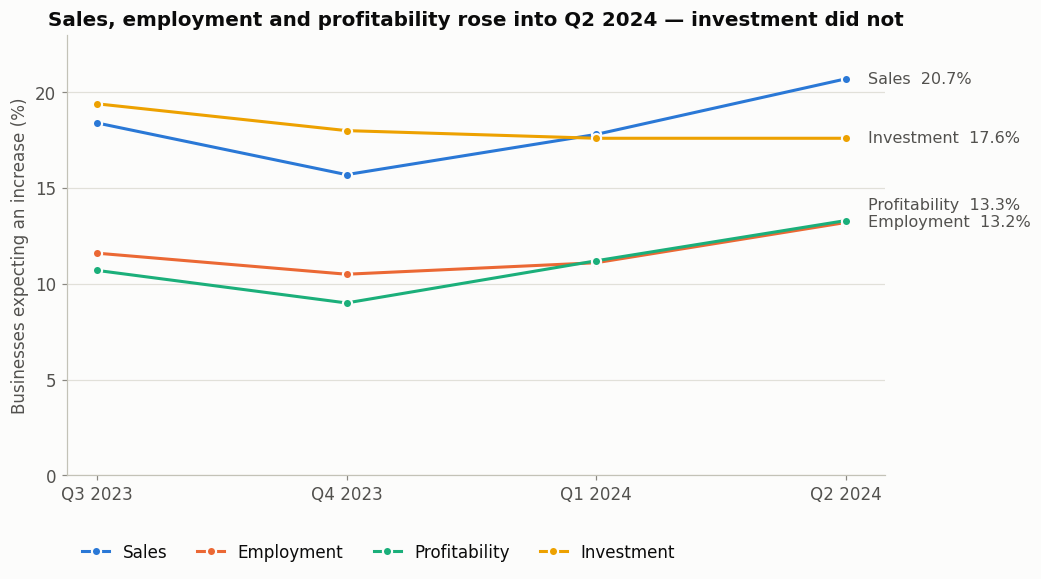

wrote outputs/analysis_1_metrics.csv


In [ ]:
csbc.national_increase_chart(
    csbc_data, csbc.OUTPUT_DIR / "analysis_1_national_increase_trend.png",
    title="Sales, employment and profitability rose into Q2 2024 — investment did not",
)
national.to_csv(csbc.OUTPUT_DIR / "analysis_1_metrics.csv")
print("wrote outputs/analysis_1_metrics.csv")

## Is comparing these four side by side fair?

A reasonable objection: notebook `02` showed the metrics have different answer rates: 16% of
businesses give no direction on investment, against none on employment. If the denominators differ,
is "investment is lower" really a like-for-like comparison?

Two answers, and the analysis needs both.

**First, on the survey's own definition the comparison is valid.** `VALUE` is the percentage of
*all* business owners in the group giving that answer, so every share already sits on the same
denominator, all businesses. "17.6% plan to increase investment" and "20.7% expect sales to rise"
are directly comparable statements about the same population.

**Second, the conclusion survives the alternative definition anyway.** Rescaling each share to only
those who gave a direction is the sterner test:

In [ ]:
# Rescale each metric's increase share to the businesses who actually gave a direction,
# to check the ranking is not an artefact of different answer rates.
national_all = csbc_data[
    (csbc_data["GEO"] == "Canada")
    & (csbc_data["Business_characteristics"] == csbc.ALL_INDUSTRIES)
]
by_direction = national_all.pivot_table(
    index=["Business_information", "Quarter"], columns="Expected_change",
    values="VALUE", aggfunc="first", dropna=False,
)

fairness = pd.DataFrame({
    "raw increase %": by_direction["increase"],
    "answered base": by_direction[csbc.DIRECTION_ORDER].sum(axis=1, skipna=False),
})
fairness["rescaled increase %"] = (
    fairness["raw increase %"] / fairness["answered base"] * 100
).round(1)

# Metric-major, quarters chronological - the default index sorts 'Q1 2024' before 'Q3 2023'.
fairness.round(1).reindex(
    pd.MultiIndex.from_product([csbc.METRIC_ORDER, QUARTERS],
                               names=["Business_information", "Quarter"])
)

raw increase %  answered base  rescaled increase %
Business_information Quarter                                                    
Sales                Q3 2023            18.4           96.6                 19.0
                     Q4 2023            15.7           96.6                 16.3
                     Q1 2024            17.8           96.2                 18.5
                     Q2 2024            20.7            NaN                  NaN
Employment           Q3 2023            11.6          100.0                 11.6
                     Q4 2023            10.5          100.0                 10.5
                     Q1 2024            11.1          100.0                 11.1
                     Q2 2024            13.2            NaN                  NaN
Profitability        Q3 2023            10.7           97.1                 11.0
                     Q4 2023             9.0           97.3                  9.2
                     Q1 2024            11.2           97.4                 11.5
                     Q2 2024            13.3            NaN                  NaN
Investment           Q3 2023            19.4           84.7                 22.9
                     Q4 2023            18.0           85.1                 21.2
                     Q1 2024            17.6           83.9                 21.0
                     Q2 2024            17.6            NaN                  NaN

Rescaled to the answered base, investment's increase share still **falls** across the three complete
quarters: 22.9% → 21.2% → 21.0%. The direction of the finding does not depend on which denominator
is used.

Note the blanks in Q2 2024: that quarter cannot be rescaled at all, because its `decrease` cells are
exactly the seven missing values from notebook `01`. Which is itself a reason to prefer the raw
observed share as the headline measure, it is the only one available for every quarter.

## Interpretation

Sales, employment and profitability increase-expectations all reached their **highest level in the
four-quarter window** in Q2 2024. Sales rose **+2.9 pp** (17.8% → 20.7%); employment and
profitability each rose **+2.1 pp**. On the face of it, a broad improvement in near-term operating
expectations.

**Investment is the exception**, flat at **17.6%** and still below its **19.4%** Q3 2023 level. It is
the only metric that did not participate in the recovery, and notebook `02` explains why that is not
merely a lag: investment expectations are statistically independent of the other three
(mean r = 0.10), and one business in six has no investment direction to report at all. Investment is
a **different decision**, not a slower-moving version of the same one.

**What I would tell a stakeholder.** Q2 2024 is a genuine improvement in how businesses expect to
trade over the next three months, but it is not yet a broad-based recovery in confidence; firms are
more positive about activity than about committing capital. I would resist the natural narrative that
"investment will follow once sales improve": nothing in this data supports that link, and the
correlation structure argues against it. Testing it properly needs complementary indicators:
financing conditions, capacity utilisation, credit availability; that this survey does not contain.

---

**Next:** `04_analysis_sector_profitability.ipynb`: what sits underneath the national number.

